In [1]:
!nvidia-smi

Wed Jan 14 15:33:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [3]:
%pip install ultralytics supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 38.9/235.7 GB disk)


In [4]:
!yolo task=detect mode=predict model=yolo12n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv12n summary (fused): 159 layers, 2,590,824 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 2 dogs, 88.4ms
Speed: 6.1ms preprocess, 88.4ms inference, 43.3ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


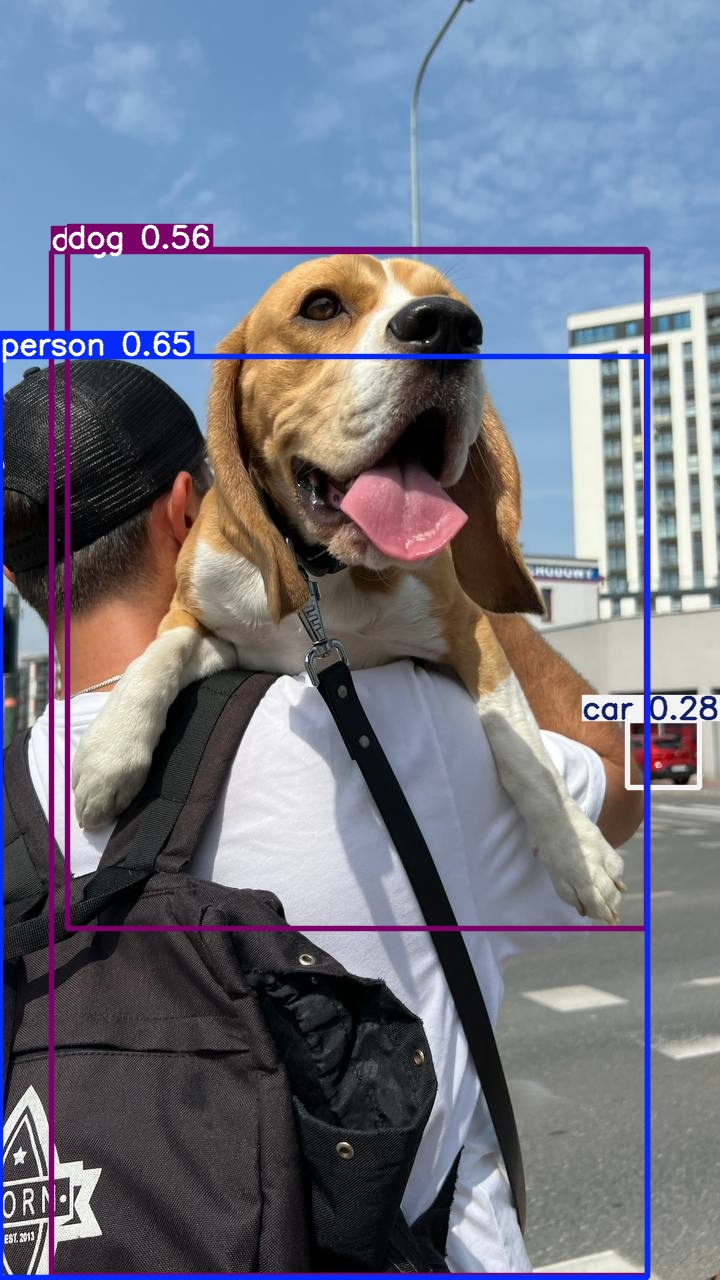

In [6]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

In [5]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo12n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 1 person, 1 car, 2 dogs, 97.4ms
Speed: 2.9ms preprocess, 97.4ms inference, 18.6ms postprocess per image at shape (1, 3, 640, 384)


In [7]:
result.boxes.xyxy

tensor([[2.3895e-01, 3.5632e+02, 6.4729e+02, 1.2772e+03],
        [6.7407e+01, 2.4999e+02, 6.4616e+02, 9.2832e+02],
        [5.1955e+01, 2.5119e+02, 6.4709e+02, 1.2750e+03],
        [6.2766e+02, 7.2023e+02, 6.9907e+02, 7.8794e+02]], device='cuda:0')

In [8]:
result.boxes.conf

tensor([0.6470, 0.5571, 0.5157, 0.2775], device='cuda:0')

In [9]:
result.boxes.cls

tensor([ 0., 16., 16.,  2.], device='cuda:0')

In [10]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

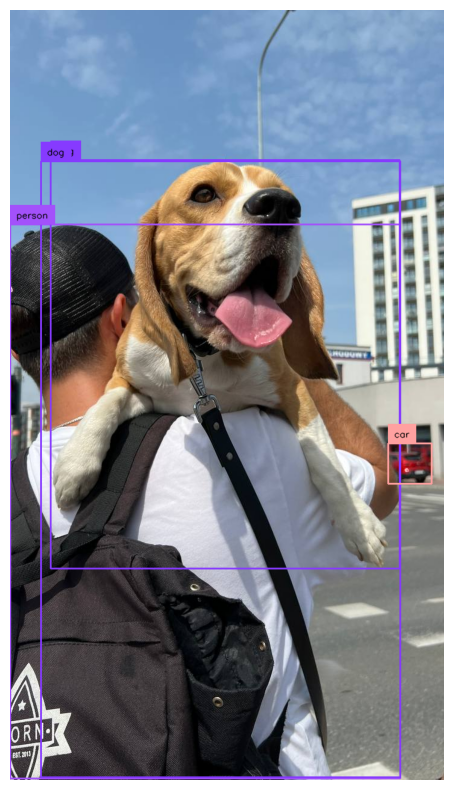

In [11]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

In [12]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("renaire-odarve")
project = workspace.project("erotica-detection")
version = project.version(4)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to erotica-detection-4 in yolov11:: 100%|██████████| 31628/31628 [00:03<00:00, 8665.75it/s]


In [13]:
%cd {HOME}

!yolo task=detect mode=train model=yolo12n.pt data={dataset.location}/data.yaml epochs=150 imgsz=640 plots=True

/content
Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/erotica-detection-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

In [14]:
!ls {HOME}/runs/detect/train/

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg      val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch96880.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch96881.jpg  weights
labels.jpg			 train_batch96882.jpg


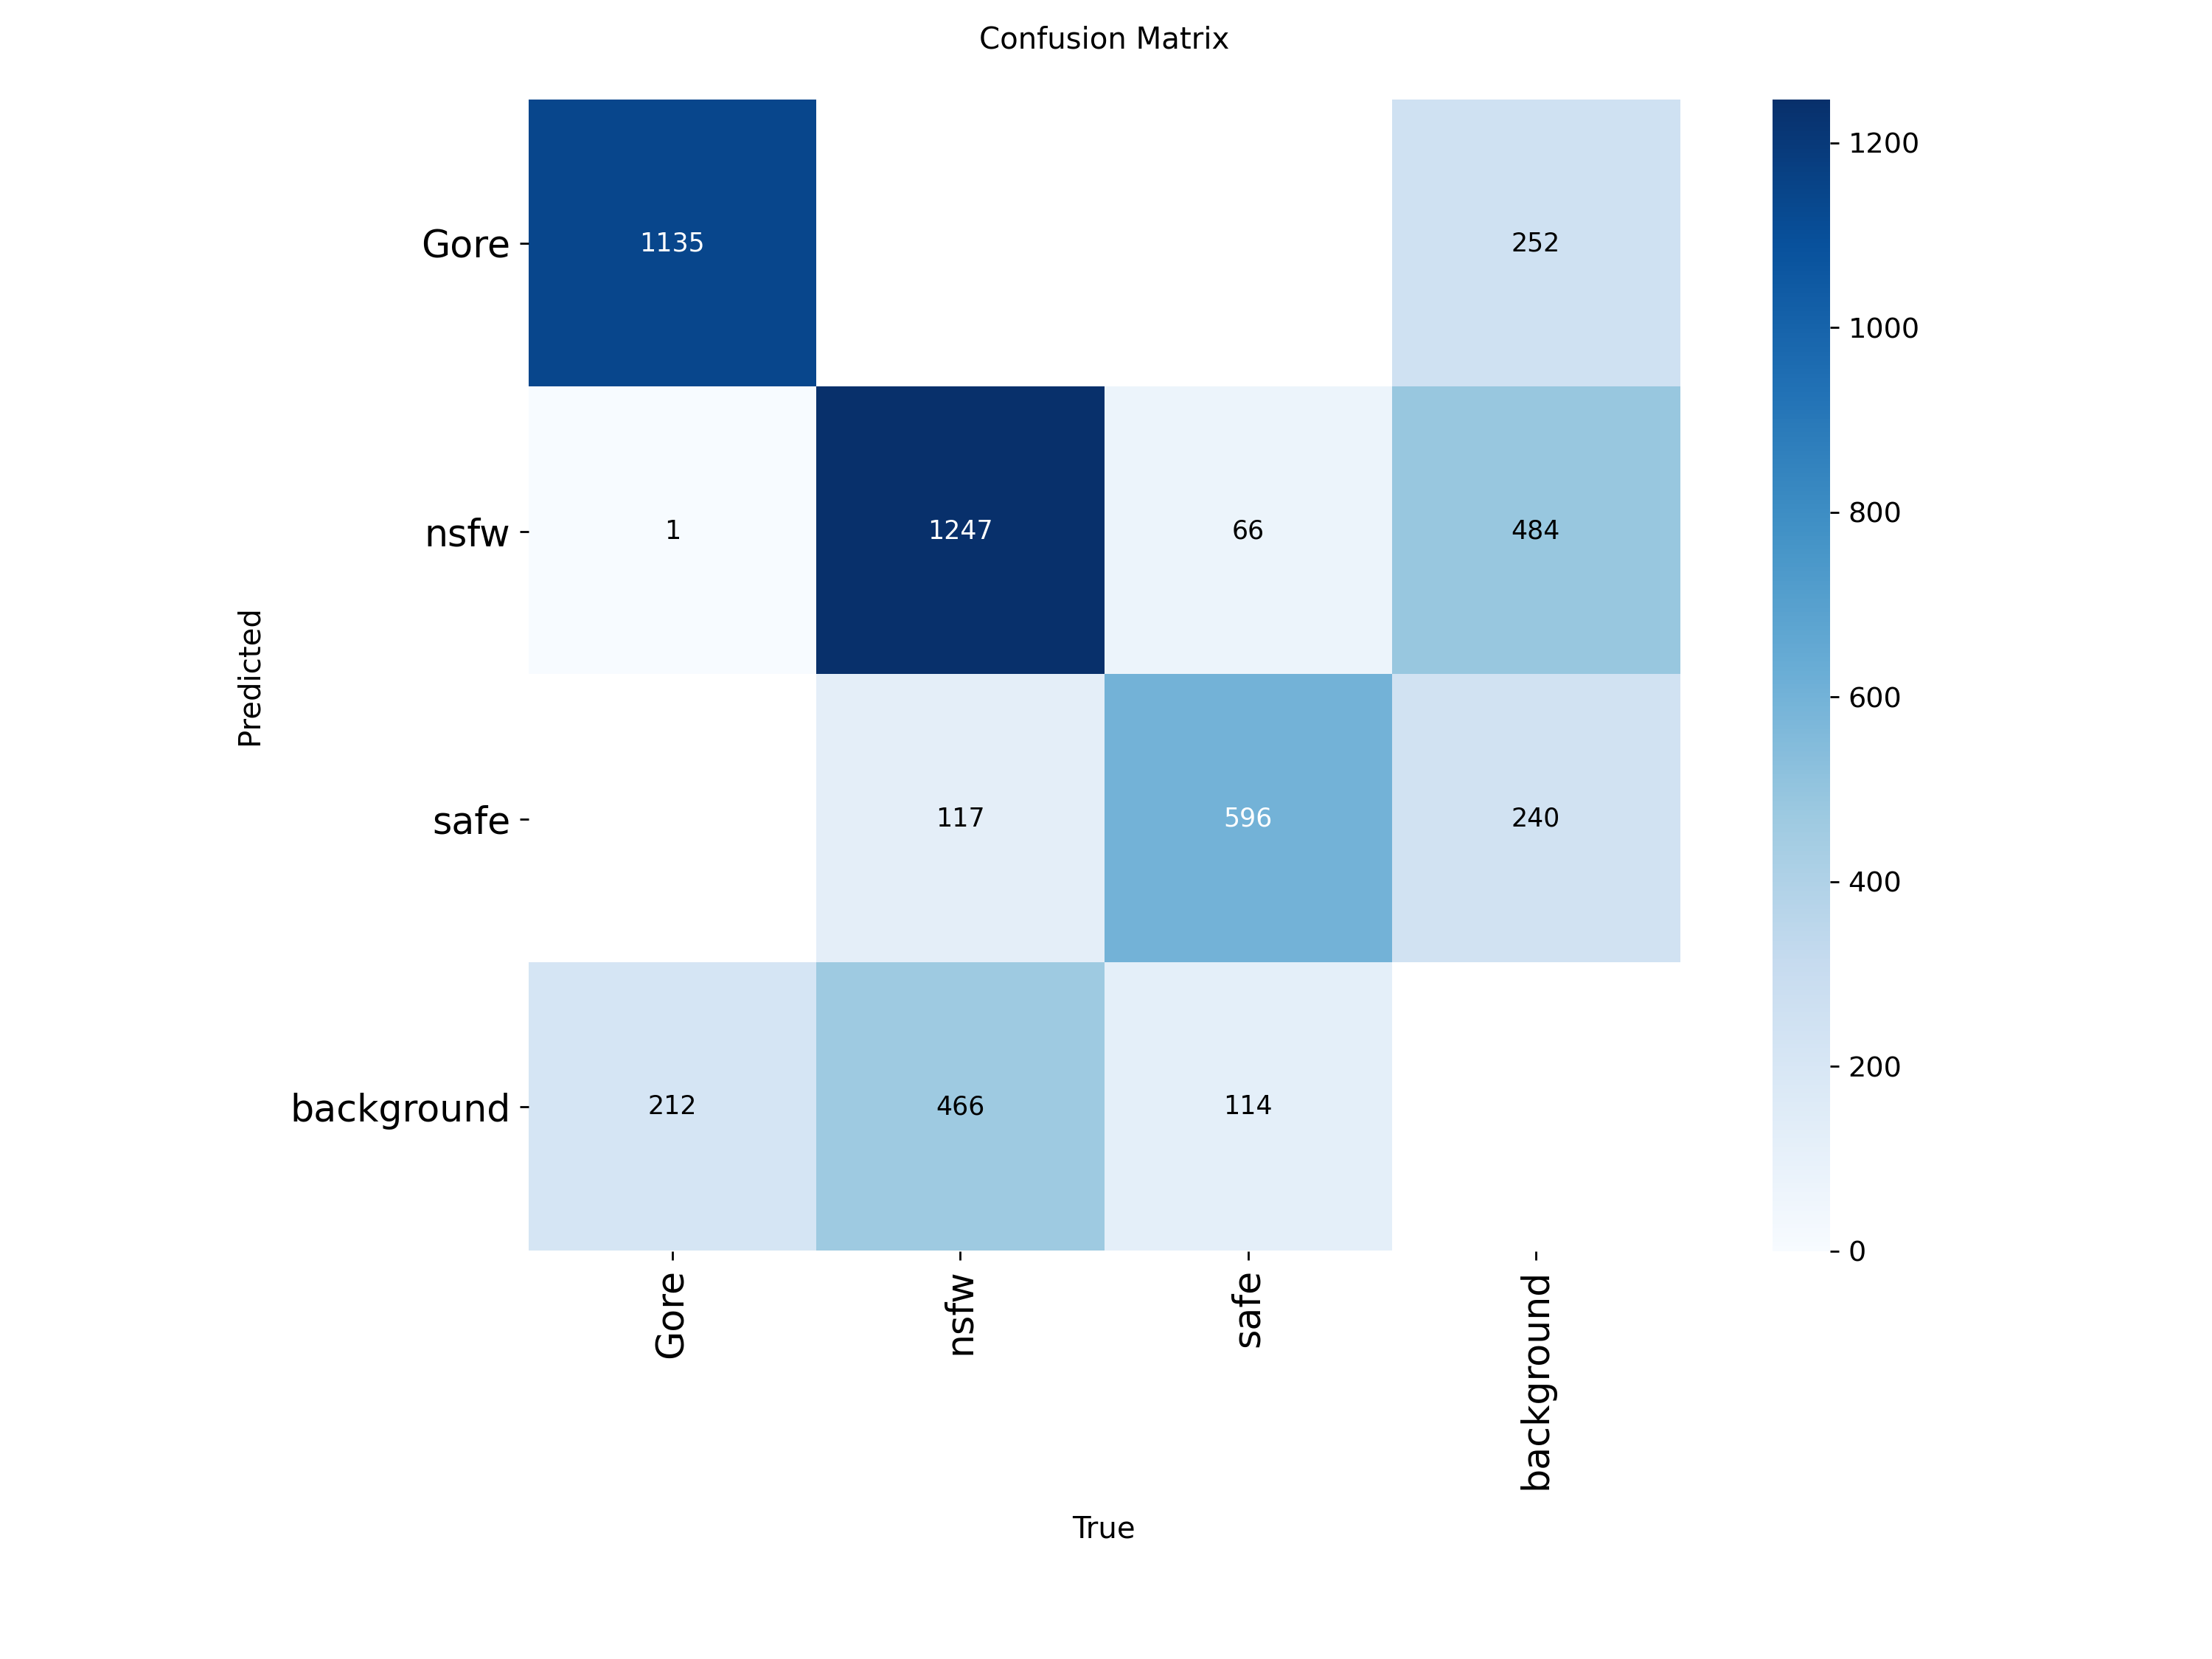

In [15]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

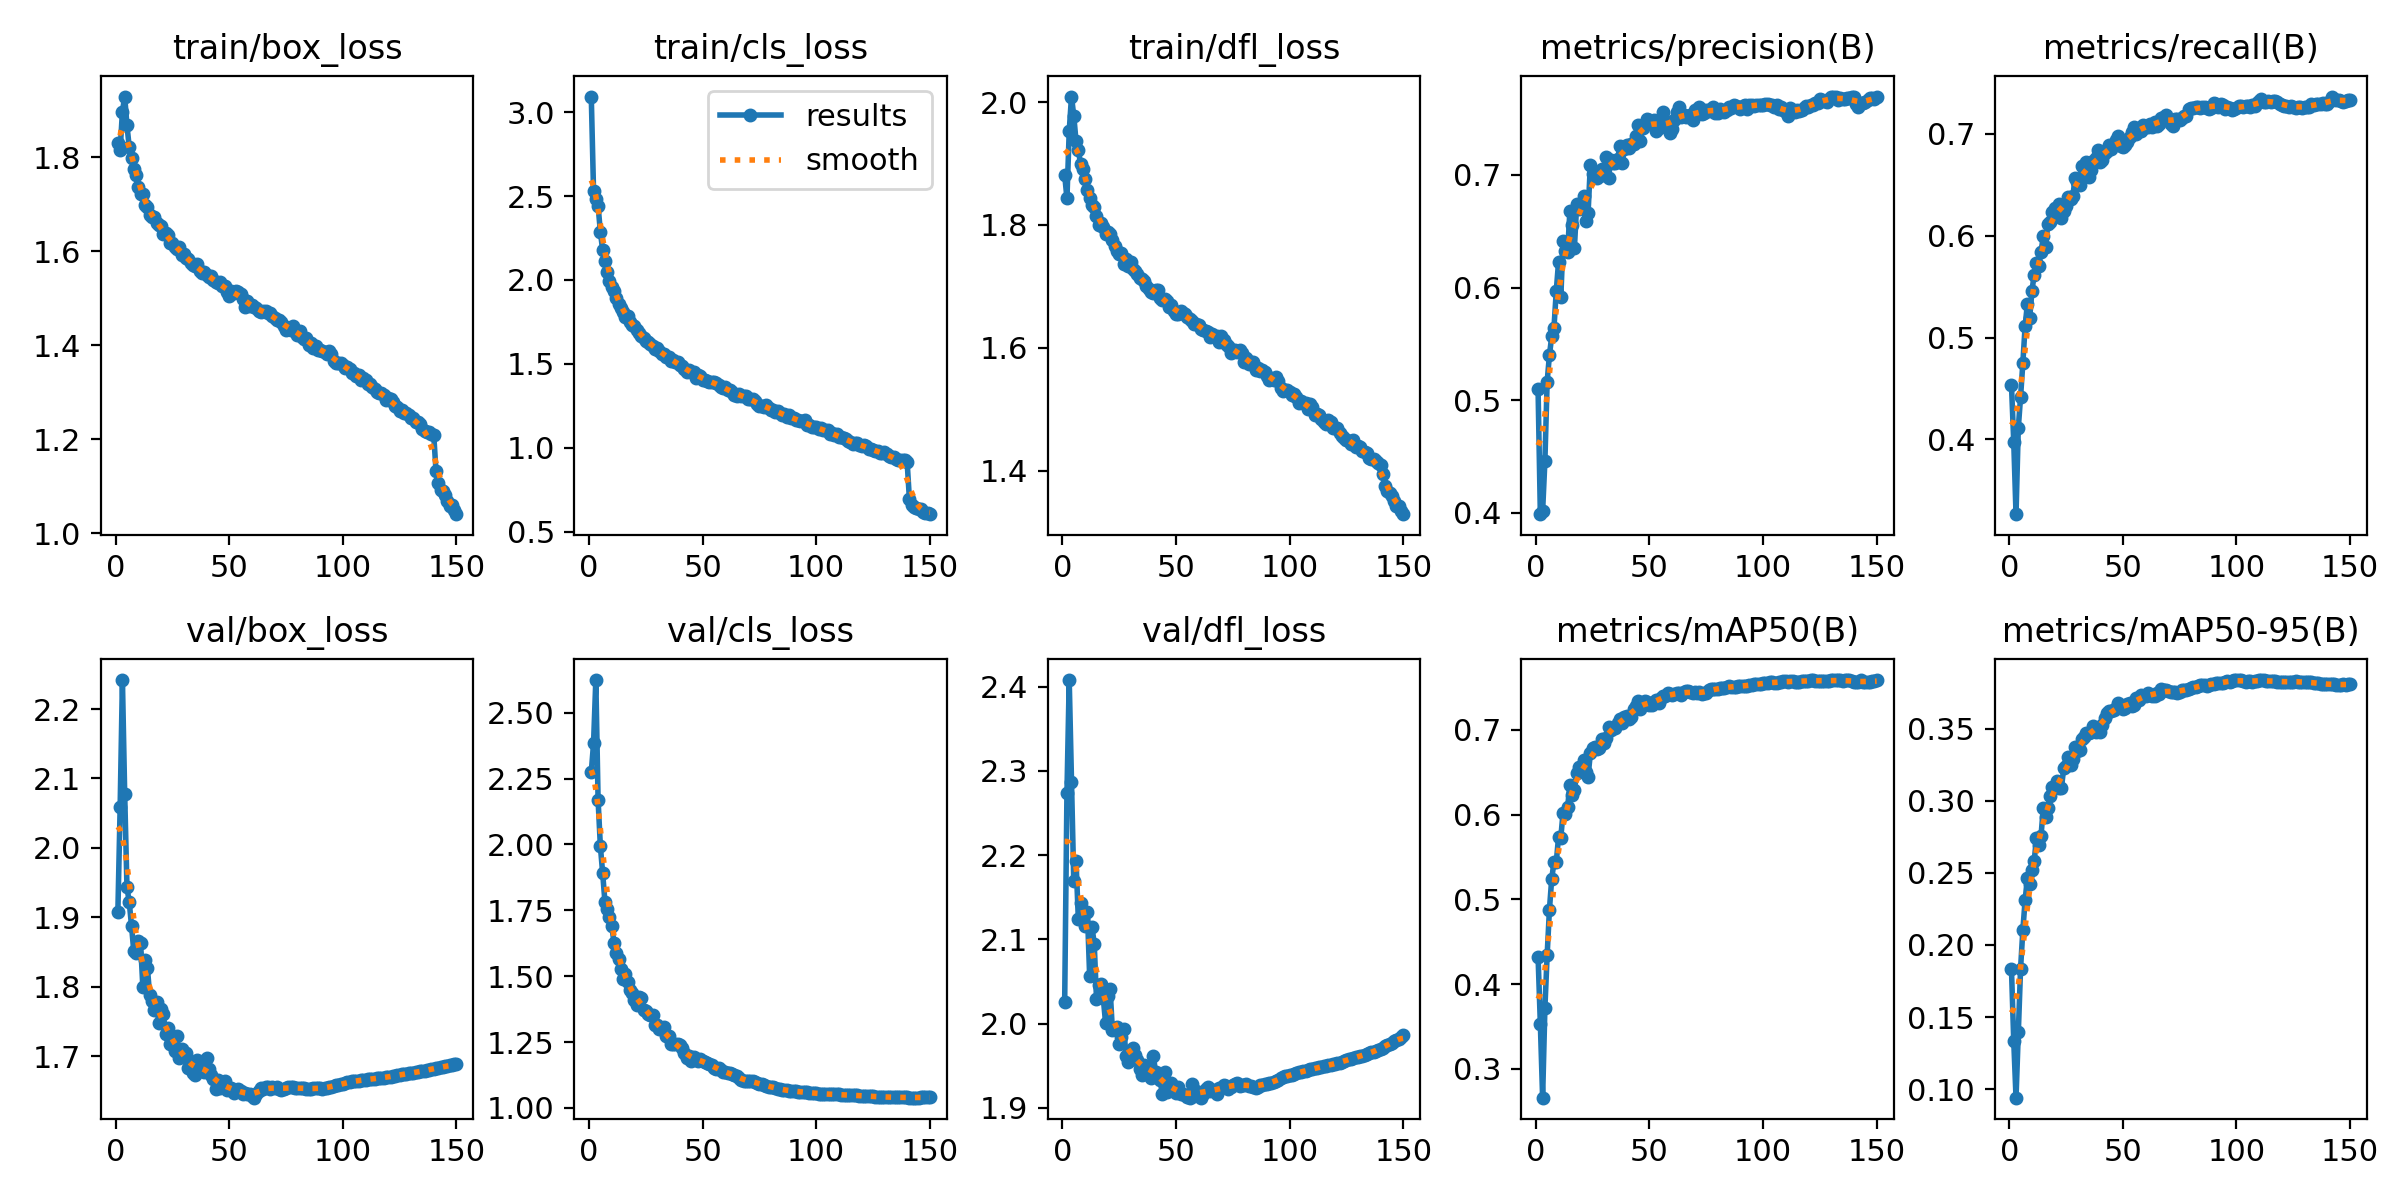

In [16]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

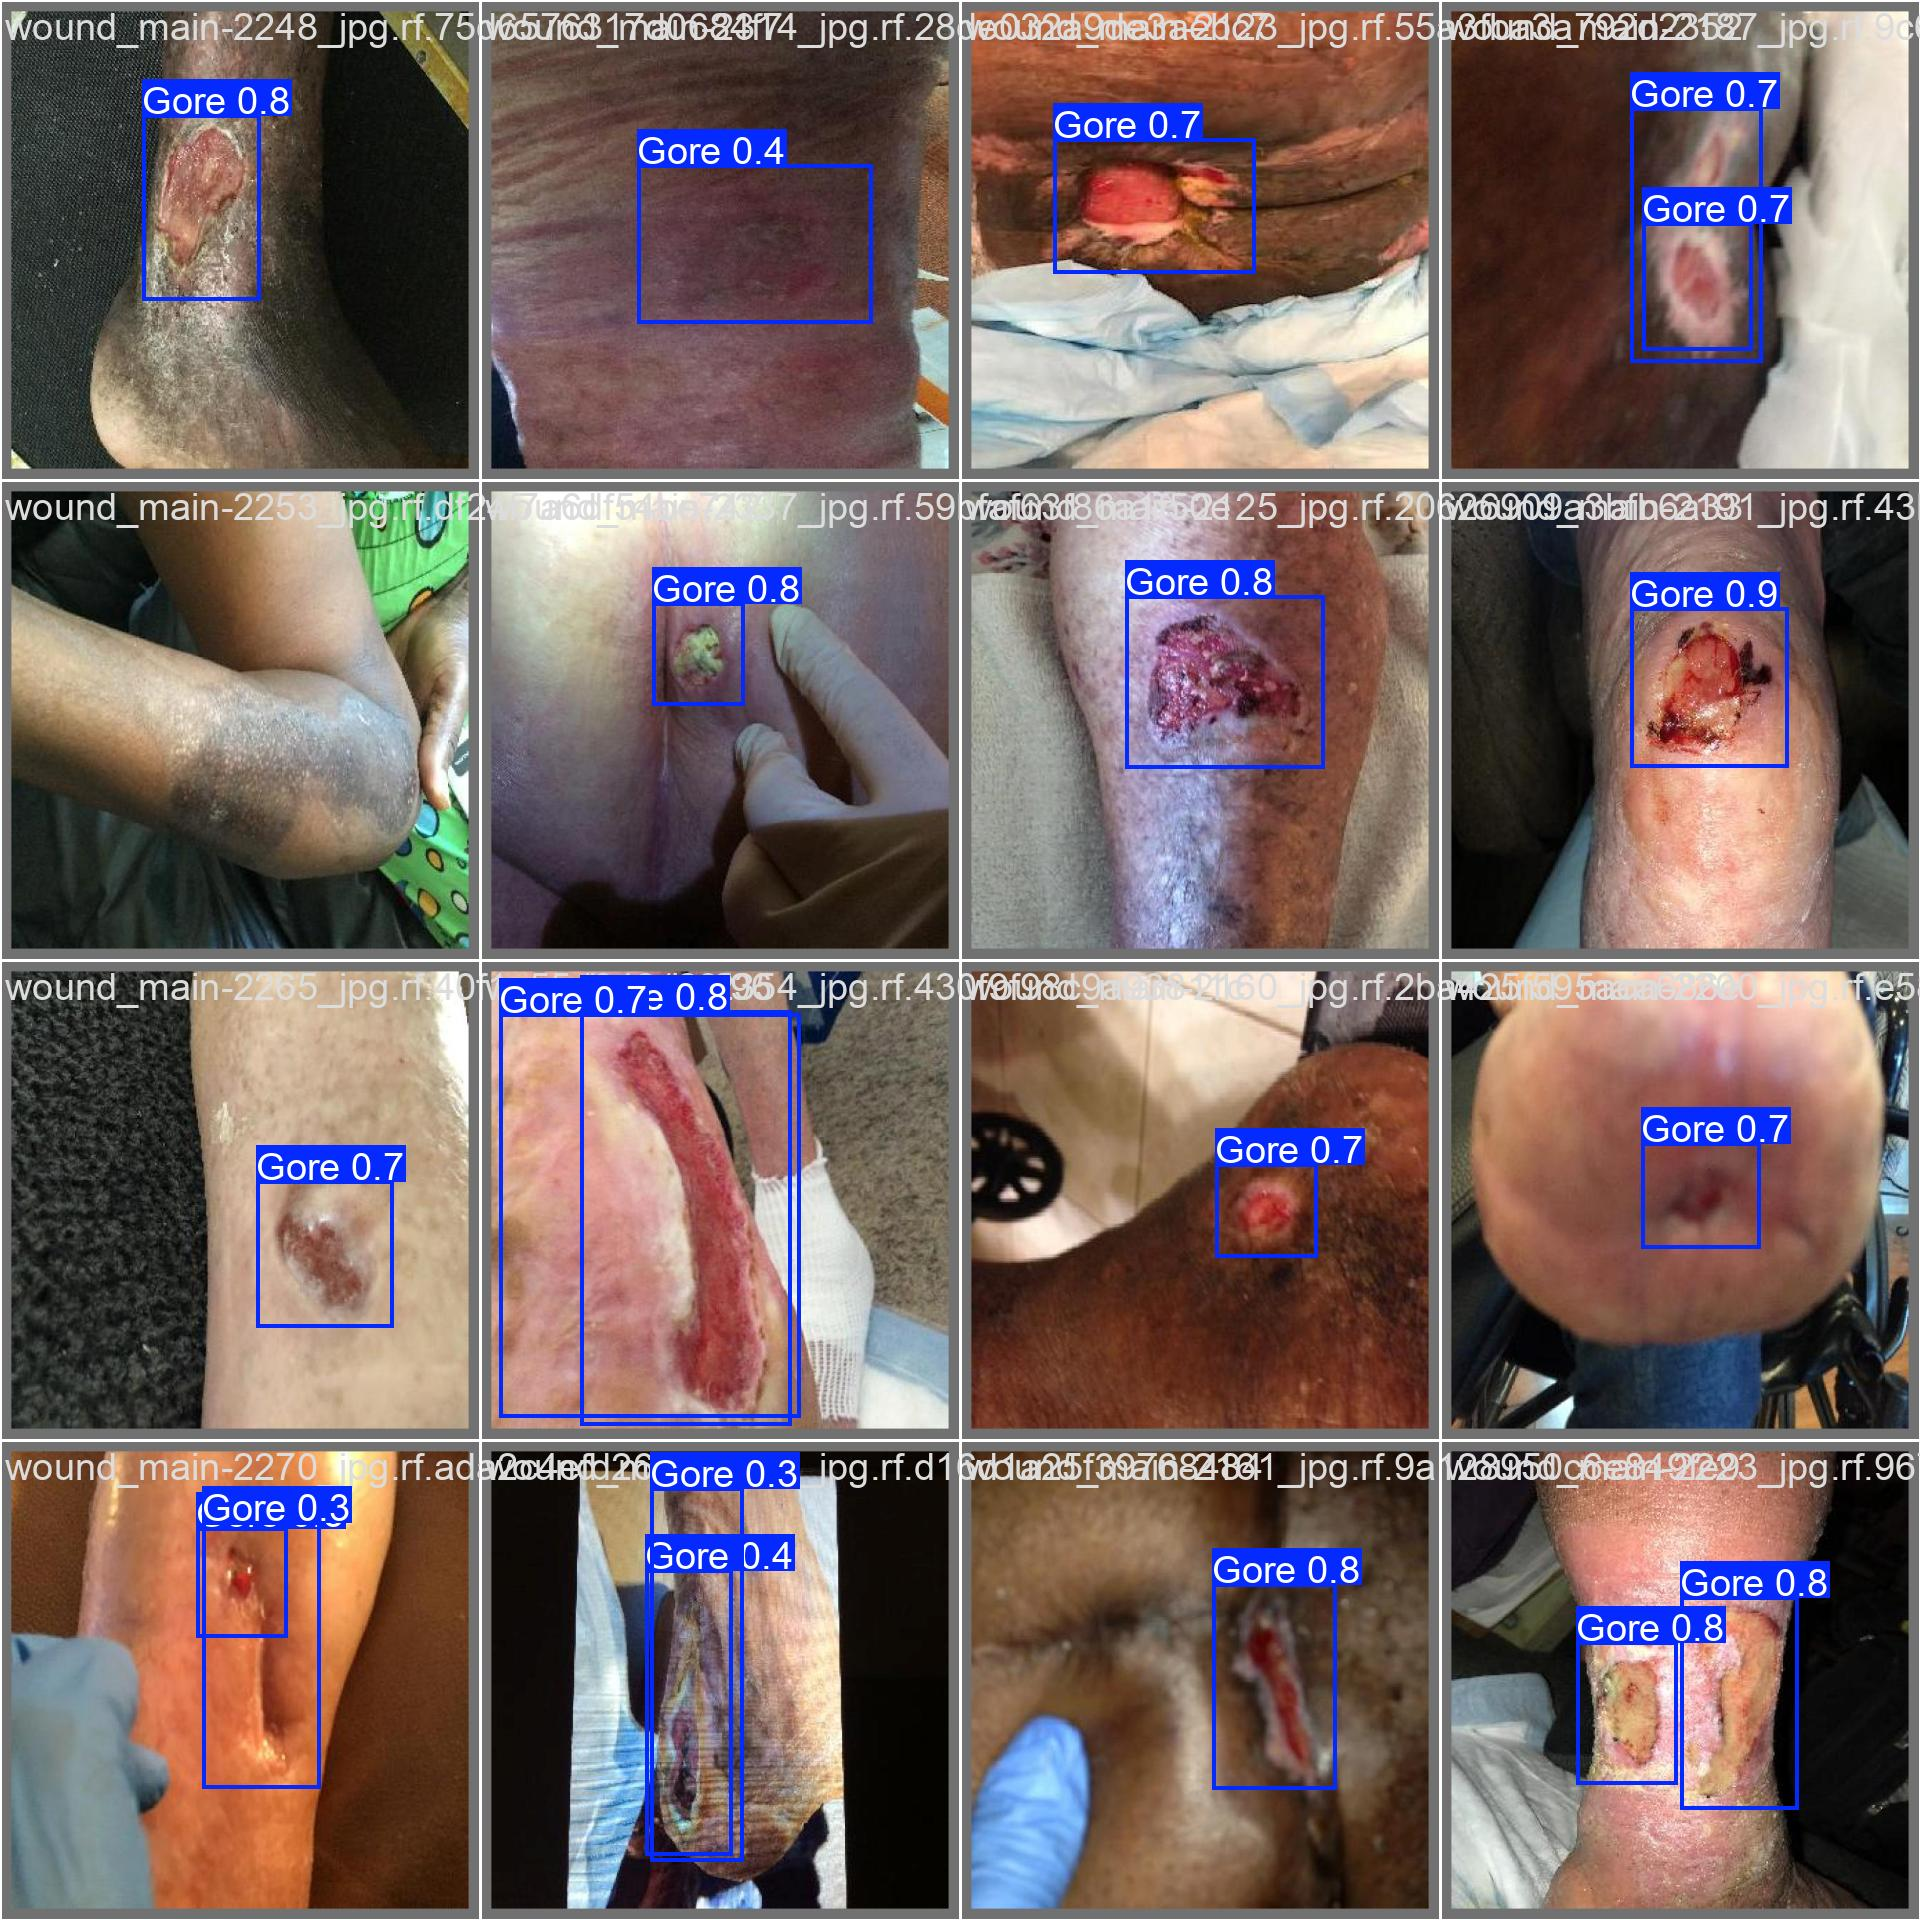

In [17]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [18]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1650.9±591.1 MB/s, size: 47.7 KB)
val: Scanning /content/datasets/erotica-detection-4/valid/labels.cache... 2416 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2416/2416 361.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 151/151 12.2it/s 12.4s
                   all       2416       3954      0.762      0.725      0.754      0.383
                  Gore       1025       1348      0.857       0.81      0.884      0.537
                  nsfw        978       1830      0.749      0.637      0.691      0.316
                  safe        520        776      0.681      0.727      0.688      0.297
Speed: 0.7ms preprocess, 1.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results save

In [19]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs

image 1/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0000-978B3Ab05B7D2D1179E42B02C89Bd98875D1Bd38-01E2H07W3_jpg.rf.fdd846755455ae656df403e62f440965.jpg: 640x640 1 nsfw, 14.1ms
image 2/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0001-6-01G12Q6Djrcnq295Zx6Tpnwtaw1680X0_jpg.rf.dd8fb3ba0cc82f539367f433c03e747e.jpg: 640x640 2 nsfws, 14.3ms
image 3/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0005-10-01G145H5V5Z86Gfbhhzqfbqkbv1680X0_jpg.rf.b88ff47921aa69035cc45a3f4ea578a6.jpg: 640x640 2 nsfws, 13.9ms
image 4/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0007-K15Ujdhhans81-01G0N767Qxfk8F3Bpvkdbg8Bws640X0_jpg.rf.6fab970148da2e8dfeb8db40f7cf0803.jpg: 640x640 2 nsfws, 13.8ms
image 5/2327 /content/datasets/erotica-detection-4/test/images/9Cl

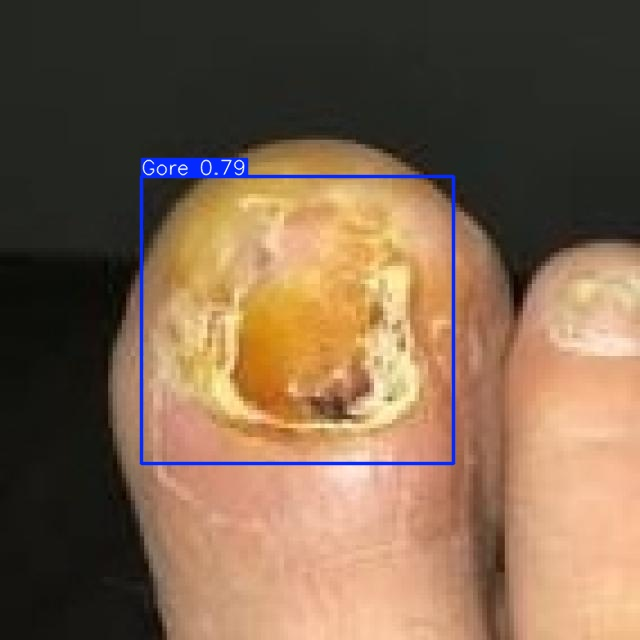

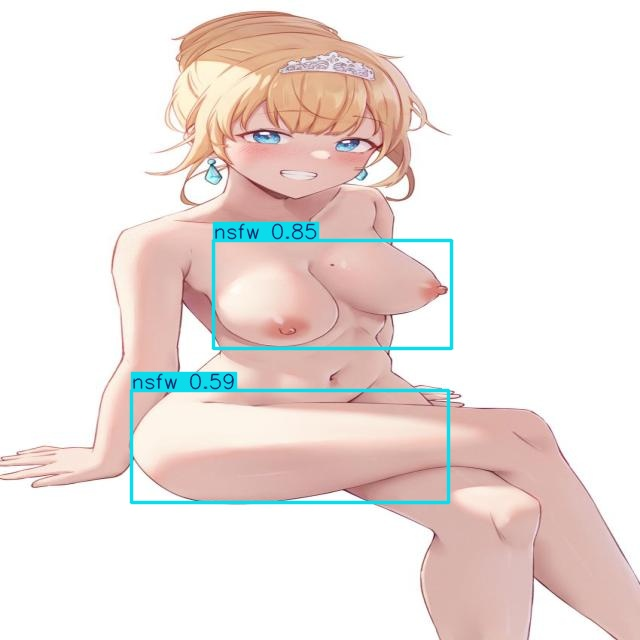

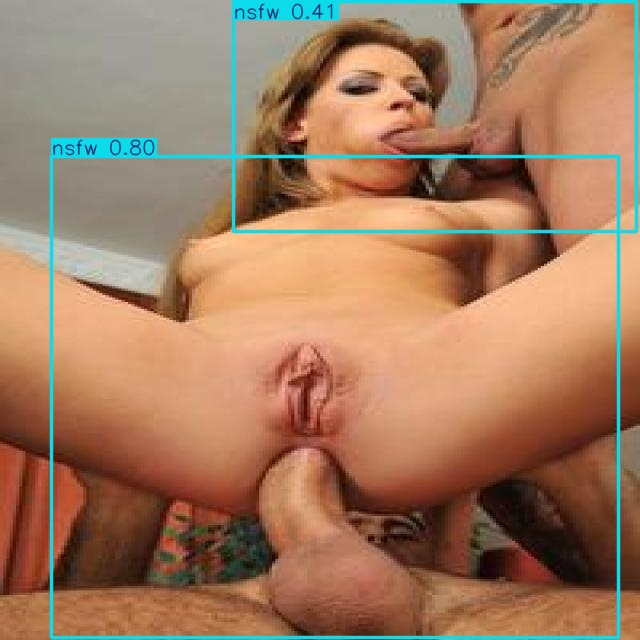

In [20]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [21]:
model.export(format="tflite")

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv12n summary (fused): 159 layers, 2,590,824 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo12n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.3 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 20 packages in 8.83s
Prepared 11 packages in 3.80s
Installed 11 packages in 261ms
 + ai-edge-litert==2.1.0
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.1
 + onnx-graphsurgeon==0.5.8
 + onnx2tf==1.28.8
 + onnxruntime-gpu==1.23.2


Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 2.6s, saved as 'yolo12n.onnx' (10.3 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 51.3files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at 'yolo12n_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 84, 8400), dtype=tf.float32, name=None)
Captures:
  138834673936400: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138834673932176: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  138834673935440: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  138834673939856: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138834673941008: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.f

'yolo12n_saved_model/yolo12n_float32.tflite'

In [22]:
# Zip the results folder
!zip -r yolov12n_results.zip /content/runs/detect/train/

  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/BoxR_curve.png (deflated 10%)
  adding: content/runs/detect/train/confusion_matrix_normalized.png (deflated 26%)
  adding: content/runs/detect/train/confusion_matrix.png (deflated 28%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 3%)
  adding: content/runs/detect/train/val_batch1_labels.jpg (deflated 7%)
  adding: content/runs/detect/train/val_batch2_pred.jpg (deflated 10%)
  adding: content/runs/detect/train/train_batch96882.jpg (deflated 4%)
  adding: content/runs/detect/train/weights/ (stored 0%)
  adding: content/runs/detect/train/weights/last.pt (deflated 11%)
  adding: content/runs/detect/train/weights/best.pt (deflated 11%)
  adding: content/runs/detect/train/BoxF1_curve.png (deflated 10%)
  adding: content/runs/detect/train/train_batch0.jpg (deflated 3%)
  adding: content/runs/detect/train/labels.jpg (deflated 25%)
  adding: content/runs/detect/train/args.yaml (deflated 53%)
 

In [23]:
# Zip the saved model folder
!zip -r yolov12n_saved_model.zip /content/yolo12n_saved_model

  adding: content/yolo12n_saved_model/ (stored 0%)
  adding: content/yolo12n_saved_model/yolo12n_float32.tflite (deflated 18%)
  adding: content/yolo12n_saved_model/saved_model.pb (deflated 12%)
  adding: content/yolo12n_saved_model/yolo12n_float16.tflite (deflated 19%)
  adding: content/yolo12n_saved_model/variables/ (stored 0%)
  adding: content/yolo12n_saved_model/variables/variables.data-00000-of-00001 (deflated 11%)
  adding: content/yolo12n_saved_model/variables/variables.index (deflated 58%)
  adding: content/yolo12n_saved_model/fingerprint.pb (stored 0%)
  adding: content/yolo12n_saved_model/metadata.yaml (deflated 45%)
  adding: content/yolo12n_saved_model/assets/ (stored 0%)


In [24]:
from google.colab import files

files.download('yolov12n_results.zip')

files.download('yolov12n_saved_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>